# ODMR Single File Fitting and Extraction
This notebook fits the ODMR spectrum from `ODMR_avg_99-6dBm_0mW.csv` using the global Lorentzian triplet model from the fitlorenzo notebook, extracts all parameters needed for the NV left-dip A response matrix, and analyzes the slopes at the leftmost minima of each of the 8 ODMR dips.

## 1. Import Required Libraries and fitlorenzo Functions
Import numpy, pandas, matplotlib, and all necessary fitting functions from the fitlorenzo notebook.

In [1]:
# 1. Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from fitlorenzo_functions import fit_global_odmr, make_global_odmr_model
GAMMA_E_MHZ_PER_MT = 28.02495164



## 2. Load ODMR Data from CSV
Load the `ODMR_avg_99-6dBm_0mW.csv` file using pandas and inspect the data structure.

In [2]:
# Load the ODMR data
csv_path = Path('../data/ODMR_avg_99-6dBm_0mW.csv')
df = pd.read_csv(csv_path, sep='\t')
display(df.head())
print(f"Data shape: {df.shape}")

,Frequency,Pixel(95-95)
0,2.770000e+09,0.077997
1,2.770200e+09,0.077922
2,2.770400e+09,0.077767
3,2.770600e+09,0.077958
4,2.770800e+09,0.078015


Data shape: (1000, 2)


## 3. Fit ODMR Data Using fitlorenzo Functions
Apply the fitting functions from fitlorenzo to the loaded ODMR data to obtain fit parameters.

In [3]:
# 3. Fit ODMR
results_df, pairs_df, payload = fit_global_odmr(df)

print("Fit success:", payload.get("fit_success", "missing"))
print("Fit status :", payload.get("fit_status", "missing"))
print("Fit message:", payload.get("fit_message", "missing"))
print("D_eff_GHz  :", payload.get("D_eff_GHz"))
print("delta_hf_MHz:", payload.get("delta_hf_GHz", np.nan) * 1000.0)
print("width_L_MHz :", payload.get("width_L_GHz", np.nan) * 1000.0)
print("global_rms  :", payload.get("global_rms"))
print(payload.keys())

display(results_df)
display(pairs_df)

Fit success: True
Fit status : 2
Fit message: `ftol` termination condition is satisfied.
D_eff_GHz  : 2.8702743980292906
delta_hf_MHz: 2.1721279276978156
width_L_MHz : 1.293202532559542
global_rms  : 0.012312723958161935
dict_keys(['f_hz', 'f_ghz', 'y_raw', 'y_norm', 'y_smooth', 'baseline_raw', 'baseline_coeffs', 'baseline_mask', 'y_fit', 'y_model', 'residuals', 'dip_centers_init', 'dip_prominences', 'centers_fit', 'centers_err', 'contrasts_fit', 'contrasts_err', 'delta_hf_GHz', 'delta_hf_err_GHz', 'width_L_GHz', 'width_L_err_GHz', 'weights_fit', 'D_guess_GHz', 'D_eff_GHz', 'global_rms', 'popt', 'pcov', 'perr', 'fit_success', 'fit_status', 'fit_message'])


,dip_id,dip_side,center_GHz,center_err_MHz,x0_GHz,x1_GHz,x2_GHz,contrast,contrast_err,hf01_MHz,hf12_MHz,delta_hf_MHz,delta_hf_err_MHz,lorentz_fwhm_MHz,lorentz_fwhm_err_MHz,w_m1,w_0,w_p1,global_fit_rms,D_eff_GHz
0,1,left,2.791164,0.054547,2.788991,2.791164,2.793336,0.281413,0.020758,2.172128,2.172128,2.172128,0.019628,1.293203,0.037019,0.340836,0.320457,0.338707,0.012313,2.870274
1,2,left,2.793645,0.272656,2.791473,2.793645,2.795817,0.044784,0.016809,2.172128,2.172128,2.172128,0.019628,1.293203,0.037019,0.340836,0.320457,0.338707,0.012313,2.870274
2,3,left,2.803903,0.042429,2.801731,2.803903,2.806075,0.253583,0.013927,2.172128,2.172128,2.172128,0.019628,1.293203,0.037019,0.340836,0.320457,0.338707,0.012313,2.870274
3,4,left,2.806457,0.352928,2.804285,2.806457,2.808629,0.031118,0.013475,2.172128,2.172128,2.172128,0.019628,1.293203,0.037019,0.340836,0.320457,0.338707,0.012313,2.870274
4,5,right,2.934173,0.027593,2.932001,2.934173,2.936346,0.358026,0.011055,2.172128,2.172128,2.172128,0.019628,1.293203,0.037019,0.340836,0.320457,0.338707,0.012313,2.870274
5,6,right,2.940731,0.379615,2.938559,2.940731,2.942904,0.028762,0.010880,2.172128,2.172128,2.172128,0.019628,1.293203,0.037019,0.340836,0.320457,0.338707,0.012313,2.870274
6,7,right,2.944961,0.035201,2.942789,2.944961,2.947133,0.370100,0.016390,2.172128,2.172128,2.172128,0.019628,1.293203,0.037019,0.340836,0.320457,0.338707,0.012313,2.870274
7,8,right,2.947161,0.185571,2.944989,2.947161,2.949333,0.069210,0.015751,2.172128,2.172128,2.172128,0.019628,1.293203,0.037019,0.340836,0.320457,0.338707,0.012313,2.870274


,pair_id,left_dip_id_sorted,right_dip_id_sorted,left_center_x1_GHz,right_center_x1_GHz,left_center_x1_err_MHz,right_center_x1_err_MHz,pair_center_GHz,pair_center_minus_D_eff_MHz,splitting_GHz,splitting_MHz,zeeman_half_MHz,left_contrast,right_contrast,D_eff_GHz
0,1,1,8,2.791164,2.947161,0.054547,0.185571,2.869162,-1.112223,0.155997,155.997111,77.998556,0.281413,0.069210,2.870274
1,2,2,7,2.793645,2.944961,0.272656,0.035201,2.869303,-0.971286,0.151316,151.315971,75.657986,0.044784,0.370100,2.870274
2,3,3,6,2.803903,2.940731,0.042429,0.379615,2.872317,2.042802,0.136829,136.828586,68.414293,0.253583,0.028762,2.870274
3,4,4,5,2.806457,2.934173,0.352928,0.027593,2.870315,0.040706,0.127717,127.716576,63.858288,0.031118,0.358026,2.870274


## 4. Plot Fitted ODMR Data
Plot the original ODMR data and the fitted curve using matplotlib for visual inspection.

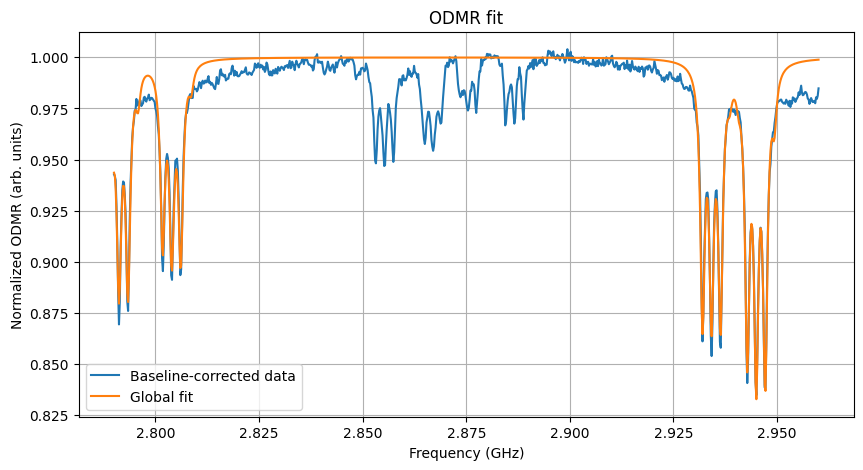

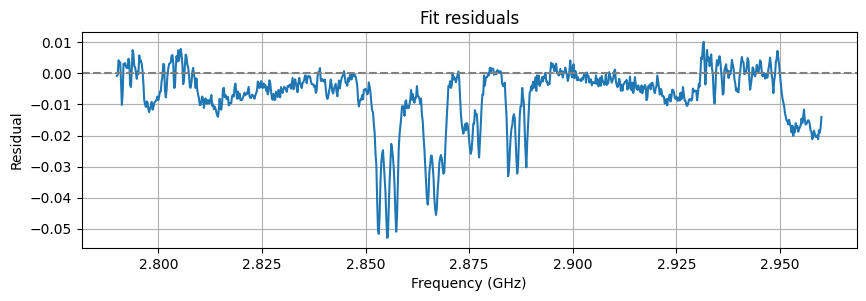

In [4]:
# 4. Plot corrected data and fit

f_ghz = payload["f_ghz"]
y_fit = payload["y_fit"]
y_model = payload["y_model"]
residuals = payload["residuals"]

plt.figure(figsize=(10, 5))
plt.plot(f_ghz, y_fit, label="Baseline-corrected data")
plt.plot(f_ghz, y_model, label="Global fit")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Normalized ODMR (arb. units)")
plt.title("ODMR fit")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 2.8))
plt.plot(f_ghz, residuals)
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Residual")
plt.title("Fit residuals")
plt.grid(True)
plt.show()

In [5]:
# 5. Show fitted line centers only

center_table = results_df[[
    "dip_id",
    "dip_side",
    "center_GHz",
    "center_err_MHz",
    "contrast",
    "lorentz_fwhm_MHz",
    "delta_hf_MHz",
    "D_eff_GHz",
]].copy()

display(center_table)

,dip_id,dip_side,center_GHz,center_err_MHz,contrast,lorentz_fwhm_MHz,delta_hf_MHz,D_eff_GHz
0,1,left,2.791164,0.054547,0.281413,1.293203,2.172128,2.870274
1,2,left,2.793645,0.272656,0.044784,1.293203,2.172128,2.870274
2,3,left,2.803903,0.042429,0.253583,1.293203,2.172128,2.870274
3,4,left,2.806457,0.352928,0.031118,1.293203,2.172128,2.870274
4,5,right,2.934173,0.027593,0.358026,1.293203,2.172128,2.870274
5,6,right,2.940731,0.379615,0.028762,1.293203,2.172128,2.870274
6,7,right,2.944961,0.035201,0.370100,1.293203,2.172128,2.870274
7,8,right,2.947161,0.185571,0.069210,1.293203,2.172128,2.870274


In [6]:
# 6. Build a dense fitted curve

model = make_global_odmr_model()
popt = payload["popt"]

f_dense = np.linspace(f_ghz.min(), f_ghz.max(), 30000)
y_dense = model(f_dense, *popt)

dy_df_dense = np.gradient(y_dense, f_dense)

# 7. Compute lock-point slopes from the fitted ODMR signal
#
# Important:
# These are NOT slopes at the minima.
# They are the steepest signal slopes near each selected resonance.
#
# This is the quantity used to convert a measured ODMR voltage change dS
# into a frequency shift dnu via:
# dnu = dS / (dS/df)
#
#Later, the A-matrix notebook converts frequency shifts into magnetic field.


In [7]:

lock_rows = []

for i in range(len(results_df)):
    fc = float(results_df.loc[i, "center_GHz"])
    dip_side = results_df.loc[i, "dip_side"]

    window = np.abs(f_dense - fc) < 0.004
    f_local = f_dense[window]
    y_local = y_dense[window]
    dy_local = dy_df_dense[window]

    idx_absmax = np.argmax(np.abs(dy_local))

    f_lock = f_local[idx_absmax]
    y_lock = y_local[idx_absmax]
    slope_lock = dy_local[idx_absmax]

    if dip_side == "left":
        dnu_dB_lowfield_MHz_per_mT = -GAMMA_E_MHZ_PER_MT
    else:
        dnu_dB_lowfield_MHz_per_mT = +GAMMA_E_MHZ_PER_MT

    slope_signal_per_GHz = slope_lock
    slope_signal_per_MHz = slope_lock / 1000.0

    lock_rows.append({
        "dip_id": int(results_df.loc[i, "dip_id"]),
        "dip_side": dip_side,
        "center_GHz": fc,
        "lock_frequency_GHz": f_lock,
        "lock_signal_arb": y_lock,
        "signal_slope_arb_per_GHz": slope_signal_per_GHz,
        "signal_slope_arb_per_MHz": slope_signal_per_MHz,
        "lowfield_dnu_dB_MHz_per_mT": dnu_dB_lowfield_MHz_per_mT,
        "conversion_dnu_per_signal_MHz_per_arb": 1.0 / slope_signal_per_MHz if np.abs(slope_signal_per_MHz) > 1e-15 else np.nan,
        "conversion_dB_per_signal_mT_per_arb": (
            1.0 / (slope_signal_per_MHz * dnu_dB_lowfield_MHz_per_mT)
            if np.abs(slope_signal_per_MHz * dnu_dB_lowfield_MHz_per_mT) > 1e-15 else np.nan
        ),
    })

lock_df = pd.DataFrame(lock_rows)
display(lock_df)

,dip_id,dip_side,center_GHz,lock_frequency_GHz,lock_signal_arb,signal_slope_arb_per_GHz,signal_slope_arb_per_MHz,lowfield_dnu_dB_MHz_per_mT,conversion_dnu_per_signal_MHz_per_arb,conversion_dB_per_signal_mT_per_arb
0,1,left,2.791164,2.793763,0.909029,105.927282,0.105927,-28.024952,9.440439,-0.336858
1,2,left,2.793645,2.793763,0.909029,105.927282,0.105927,-28.024952,9.440439,-0.336858
2,3,left,2.803903,2.806496,0.921060,91.287356,0.091287,-28.024952,10.954420,-0.390881
3,4,left,2.806457,2.806496,0.921060,91.287356,0.091287,-28.024952,10.954420,-0.390881
4,5,right,2.934173,2.931632,0.897583,-128.850584,-0.128851,28.024952,-7.760927,-0.276929
5,6,right,2.940731,2.942427,0.882065,-141.506607,-0.141507,28.024952,-7.066808,-0.252161
6,7,right,2.944961,2.947505,0.873631,153.177890,0.153178,28.024952,6.528357,0.232948
7,8,right,2.947161,2.947505,0.873631,153.177890,0.153178,28.024952,6.528357,0.232948


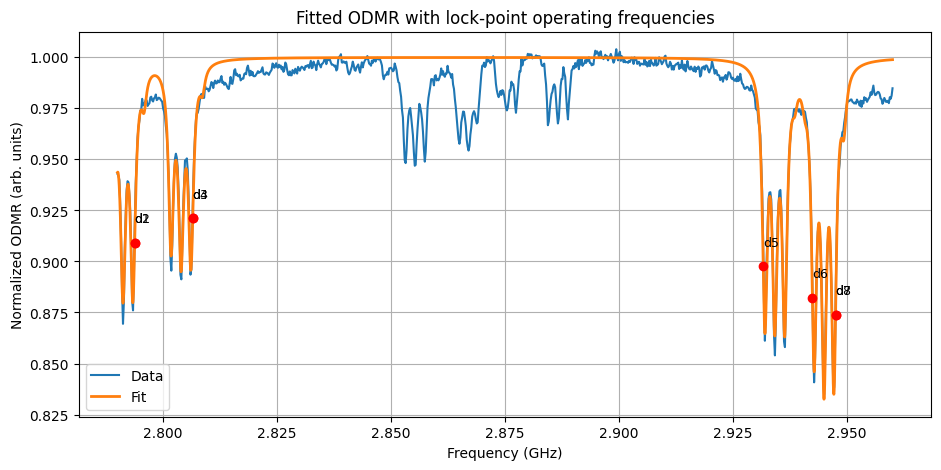

In [8]:
# 8. Plot fitted ODMR with lock points

plt.figure(figsize=(11, 5))
plt.plot(f_ghz, y_fit, label="Data")
plt.plot(f_dense, y_dense, label="Fit", linewidth=2)

for _, row in lock_df.iterrows():
    plt.plot(row["lock_frequency_GHz"], row["lock_signal_arb"], "ro")
    plt.text(row["lock_frequency_GHz"], row["lock_signal_arb"] + 0.01, f'd{int(row["dip_id"])}', fontsize=9)

plt.xlabel("Frequency (GHz)")
plt.ylabel("Normalized ODMR (arb. units)")
plt.title("Fitted ODMR with lock-point operating frequencies")
plt.legend()
plt.grid(True)
plt.show()

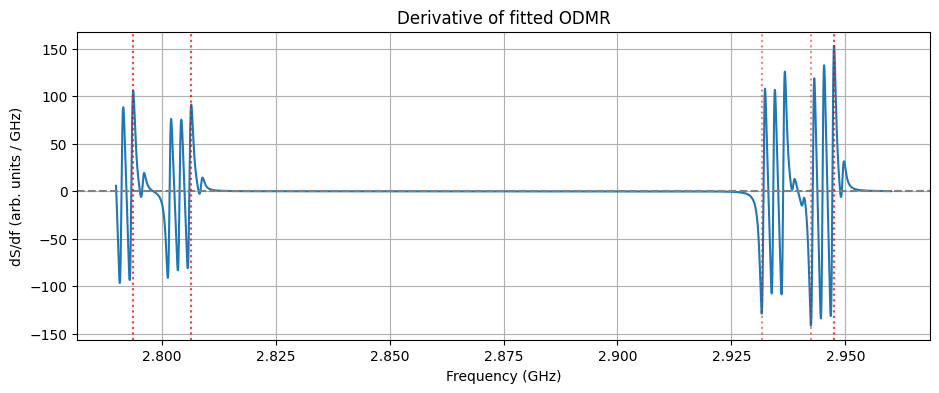

In [9]:
# 9. Plot derivative to visually inspect the lock-point slopes

plt.figure(figsize=(11, 4))
plt.plot(f_dense, dy_df_dense)
plt.axhline(0, color="gray", linestyle="--")

for _, row in lock_df.iterrows():
    plt.axvline(row["lock_frequency_GHz"], color="red", linestyle=":", alpha=0.5)

plt.xlabel("Frequency (GHz)")
plt.ylabel("dS/df (arb. units / GHz)")
plt.title("Derivative of fitted ODMR")
plt.grid(True)
plt.show()

In [10]:
# 10. Pair-level summary for later A-matrix notebook
#
# This is the key table that the later notebook will read.

pair_export_df = pairs_df.copy()

display(pair_export_df)

,pair_id,left_dip_id_sorted,right_dip_id_sorted,left_center_x1_GHz,right_center_x1_GHz,left_center_x1_err_MHz,right_center_x1_err_MHz,pair_center_GHz,pair_center_minus_D_eff_MHz,splitting_GHz,splitting_MHz,zeeman_half_MHz,left_contrast,right_contrast,D_eff_GHz
0,1,1,8,2.791164,2.947161,0.054547,0.185571,2.869162,-1.112223,0.155997,155.997111,77.998556,0.281413,0.069210,2.870274
1,2,2,7,2.793645,2.944961,0.272656,0.035201,2.869303,-0.971286,0.151316,151.315971,75.657986,0.044784,0.370100,2.870274
2,3,3,6,2.803903,2.940731,0.042429,0.379615,2.872317,2.042802,0.136829,136.828586,68.414293,0.253583,0.028762,2.870274
3,4,4,5,2.806457,2.934173,0.352928,0.027593,2.870315,0.040706,0.127717,127.716576,63.858288,0.031118,0.358026,2.870274


In [11]:
# 11. Save outputs

outdir = Path("./outputs_single_fit")
outdir.mkdir(exist_ok=True)

results_df.to_csv(outdir / "fitted_dips.csv", index=False)
pairs_df.to_csv(outdir / "paired_dips.csv", index=False)
lock_df.to_csv(outdir / "lockpoint_slopes.csv", index=False)

fit_metadata_df = pd.DataFrame([{
    "source_file": str(csv_path),
    "D_eff_GHz": payload["D_eff_GHz"],
    "delta_hf_MHz": payload["delta_hf_GHz"] * 1000.0,
    "lorentz_fwhm_MHz": payload["width_L_GHz"] * 1000.0,
    "global_rms": payload["global_rms"],
    "fit_success": payload["fit_success"],
    "fit_status": payload["fit_status"],
    "fit_message": payload["fit_message"],
    "w_m1": payload["weights_fit"][0],
    "w_0": payload["weights_fit"][1],
    "w_p1": payload["weights_fit"][2],
}])

fit_metadata_df.to_csv(outdir / "fit_metadata.csv", index=False)

curve_df = pd.DataFrame({
    "f_GHz": payload["f_ghz"],
    "y_fit": payload["y_fit"],
    "y_model": payload["y_model"],
    "residuals": payload["residuals"],
    "baseline_raw": payload["baseline_raw"],
})

curve_df.to_csv(outdir / "fit_curve_data.csv", index=False)

print("Saved outputs to:", outdir.resolve())
print(" - fitted_dips.csv")
print(" - paired_dips.csv")
print(" - lockpoint_slopes.csv")
print(" - fit_metadata.csv")
print(" - fit_curve_data.csv")

Saved outputs to: /home/vita/projects/NV_sensing/fitting_odmr/outputs_single_fit
 - fitted_dips.csv
 - paired_dips.csv
 - lockpoint_slopes.csv
 - fit_metadata.csv
 - fit_curve_data.csv
